In [21]:
import torch
import torch.nn as nn
import torch.optim as opt
import matplotlib.pyplot as plt
from torchmetrics import Accuracy
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from skorch import NeuralNetClassifier

In [22]:
X, y = make_classification(n_samples=500, n_features=15, n_informative=12, n_redundant=2, n_classes=2, random_state=0)

In [23]:
def tensor_train_test_split(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

    tX_train = torch.tensor(X_train).float()
    ty_train = torch.tensor(y_train).int().view(len(y_train), 1)
    tX_test = torch.tensor(X_test).float()
    ty_test = torch.tensor(y_test).int().view(len(y_test), 1)

    return tX_train, tX_test, ty_train, ty_test

## Example: 'hard-coded' classification neural network

In [24]:
tX_train, tX_test, ty_train, ty_test = tensor_train_test_split(X, y)

In [25]:
class HardCodedBinaryClassificationNN(nn.Module):
    def __init__(self, n_features: int):
        """ Creates a feed-forward neural network with one hidden layer
            of size 30, a ReLU activation function, and one output layer
            with no loss function.

            Note that we have two options for binary classification.
            The first would be to use a nn.Sigmoid activation function on
            the output layer, and a nn.BCELoss as the loss function during
            training. However, pytorch provides us with a more numerically
            stable nn.BCEWithLogitsLoss which combines the two above
            functions into one. Therefore, because the sigmoid is "bundled"
            inside the loss function, we do not need any activation
            function for the output layer of our neural network.
        """
        super(HardCodedBinaryClassificationNN, self).__init__()

        self.hidden_layer = nn.Linear(in_features=n_features, out_features=30)
        self.hidden_activation = nn.ReLU()
        self.output_layer = nn.Linear(in_features=30, out_features=1)

    def forward(self, X):
        """ Performs forward propagation. """
        X = X.float()
        X = self.hidden_layer(X)
        X = self.hidden_activation(X)
        X = self.output_layer(X)

        return X

In [26]:
n, p = tX_train.shape
hard_coded_nn = HardCodedBinaryClassificationNN(n_features=p)

In [27]:
optimiser = opt.Adam(hard_coded_nn.parameters(), lr=0.01)
loss_function = nn.BCEWithLogitsLoss()
acc_function = Accuracy(task='binary')
n_iterations = 200

training_loss = list()
training_acc = list()
test_acc = list()

for _ in range(n_iterations):
    optimiser.zero_grad()
    training_predictions = hard_coded_nn(tX_train)
    test_predictions = hard_coded_nn(tX_test)
    loss = loss_function(training_predictions, ty_train.float())
    
    training_loss.append(loss.item())
    training_acc.append(acc_function(training_predictions, ty_train).item())
    test_acc.append(acc_function(test_predictions, ty_test).item())

    loss.backward()
    optimiser.step()

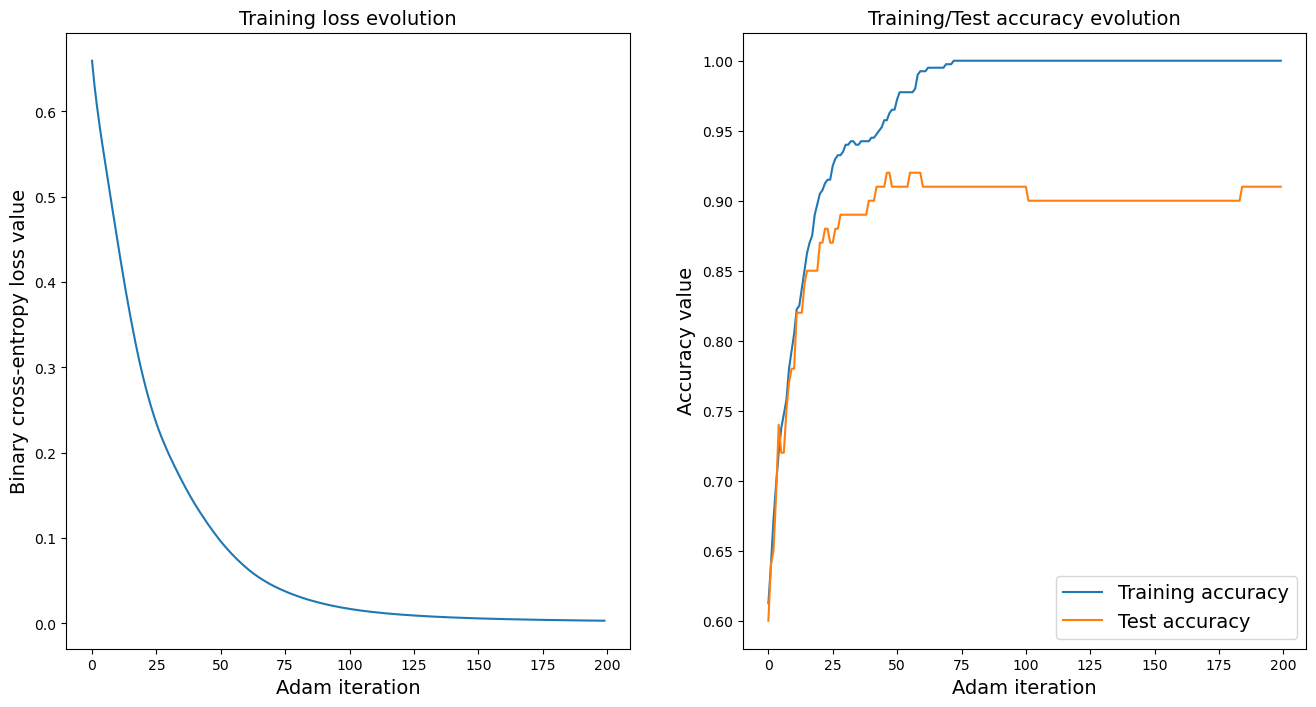

In [28]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,8))

ax = axes.flat[0]
ax.plot(range(n_iterations), training_loss)
ax.set_xlabel('Adam iteration', fontsize=14)
ax.set_ylabel('Binary cross-entropy loss value', fontsize=14)
ax.set_title('Training loss evolution', fontsize=14)

ax = axes.flat[1]
ax.plot(range(n_iterations), training_acc, label='Training accuracy')
ax.plot(range(n_iterations), test_acc, label='Test accuracy')
ax.set_xlabel('Adam iteration', fontsize=14)
ax.set_ylabel('Accuracy value', fontsize=14)
ax.set_title('Training/Test accuracy evolution', fontsize=14)
ax.legend(fontsize=14);

## Example: binary classification neural network

This example shows how to use `skorch` to add a FFNN to an `sklearn`'s pipeline and perform hyperparameter tuning using `sklearn`'s grid search machinery.

In [29]:
class SimpleBinaryClassificationNN(nn.Module):
    def __init__(self, n_features: int, n_training_pts: int, n_hidden_layers: int, gamma: int, **kwargs):
        """ Creates a simple feed-forward neural network for binary classification.

            Parameters:
                - n_features is the dimensionality of the inputs.
                    It is used to determine the size of the input layer.
                - n_training_pts is the size of the training set.
                    It is used in the rule-of-thumb to determine the width of the
                    hidden layers.
                - n_hidden_layers is the depth of the neural network.
                - gamma is the scaling parameter in the rule-of-thumb for layer widths.
                    The rule of thumb is width = n / (gamma * (K_I + K_O)), where n is
                    the size of the training set, K_I is the dimension of the input,
                    K_O is the dimension of the output (1 in our case), and gamma is
                    the scaling parameter.
                - width_multipliers is a list of n_hidden_layers positive integers.
                    It can be used to have different width for each layer.
                    The base width of the layers is computed using the rule of thumb.
                    If this parameter is passed, the i-th hidden layer's width is
                    multiplied by the entry at index i-1 of this vector.
                    For ease of use, we also handle cases when width_multipliers
                    contains less or more than n_hidden_layers positive integers.
                    In the first case, the list is completed with 1's. In the second
                    case, it is truncated.
                - hidden_activation is the activation function used by the hidden layers.
                    By default it is nn.ReLU.
                - output_activation is the activation function used by the output layer.
                    By default it is none because it is assumed that the loss
                    function already bundles the activation function of the output
                    layer. For example, nn.BCEWithLogitsLoss does so.

        """
        super(SimpleBinaryClassificationNN, self).__init__()
        
        self.n_features = n_features
        self.n_training_pts = n_training_pts
        self.n_hidden_layers = n_hidden_layers
        self.gamma = gamma
        self.width_multipliers = kwargs.get('width_multipliers', [1] * self.n_hidden_layers)
        self.hidden_activation = kwargs.get('hidden_activation', nn.ReLU)
        self.output_activation = kwargs.get('output_activation', None)

        lwm = len(self.width_multipliers)
        if lwm < self.n_hidden_layers:
            self.width_multipliers += [1] * (self.n_hidden_layers - lwm)
        elif lwm > self.n_hidden_layers:
            self.width_multipliers = self.width_multipliers[:lwm]

        self.hidden_layers = list()
        self.base_width = int(self.n_training_pts / (self.gamma * (self.n_features + 1)))

        current_input_size = self.n_features
        for width_multiplier in self.width_multipliers:
            current_output_size = int(self.base_width * width_multiplier)
            self.hidden_layers.append(nn.Linear(
                in_features=current_input_size,
                out_features=current_output_size
            ))
            self.hidden_layers.append(self.hidden_activation())
            current_input_size = current_output_size

        self.output_layers = [nn.Linear(
            in_features=current_input_size,
            out_features=1
        )]

        if self.output_activation is not None:
            self.output_layers.append(self.output_activation)

        self.stack = nn.Sequential(*self.hidden_layers, *self.output_layers)

    def forward(self, X):
        """ Performs forward propagation. """
        X = X.float()
        return self.stack(X)

In [30]:
kfold = StratifiedKFold(n_splits=5, shuffle=True)
simple_nn = NeuralNetClassifier(
    module=SimpleBinaryClassificationNN,
    criterion=nn.BCEWithLogitsLoss,
    optimizer=opt.Adam,
    train_split=None
)
pipeline = Pipeline([
    ('standardscaler', StandardScaler()),
    ('neuralnetwork', simple_nn)
])
gs = GridSearchCV(
    estimator=pipeline,
    param_grid=dict(
        neuralnetwork__module__n_features=[p],
        neuralnetwork__module__n_training_pts=[n],
        neuralnetwork__module__width_multipliers=[[4,2]],
        neuralnetwork__module__n_hidden_layers=[2,4,8],
        neuralnetwork__module__gamma=[1,5,10]
    ),
    scoring='accuracy',
    cv=kfold
)
gs.fit(tX_train, ty_train.float())

  epoch    train_loss     dur
-------  ------------  ------
      1        0.6655  0.0224
      2        0.5345  0.0235
      3        0.4037  0.0226
      4        0.2895  0.0173
      5        0.1970  0.0344
      6        0.1456  0.0872
      7        0.1007  0.0277
      8        0.0659  0.0291
      9        0.0434  0.0187
     10        0.0279  0.0112
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6759  0.0246
      2        0.5571  0.0230
      3        0.4487  0.0191
      4        0.3583  0.0282
      5        0.2796  0.0138
      6        0.2158  0.0335
      7        0.1706  0.0142
      8        0.1302  0.0342
      9        0.0972  0.0167
     10        0.0696  0.0334
  epoch    train_loss     dur
-------  ------------  ------
      1        0.6690  0.0193
      2        0.5346  0.0174
      3        0.4087  0.0219
      4        0.3021  0.0329
      5        0.2161  0.0267
      6        0.1582  0.0207
      7        0.1196  0.0294
      8   

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('neuralnetwork',
                                        <class 'skorch.classifier.NeuralNetClassifier'>[uninitialized](
  module=<class '__main__.SimpleBinaryClassificationNN'>,
))]),
             param_grid={'neuralnetwork__module__gamma': [1, 5, 10],
                         'neuralnetwork__module__n_features': [15],
                         'neuralnetwork__module__n_hidden_layers': [2, 4, 8],
                         'neuralnetwork__module__n_training_pts': [400],
                         'neuralnetwork__module__width_multipliers': [[4, 2]]},
             scoring='accuracy')

In [40]:
gs.best_params_

{'neuralnetwork__module__gamma': 1,
 'neuralnetwork__module__n_features': 15,
 'neuralnetwork__module__n_hidden_layers': 4,
 'neuralnetwork__module__n_training_pts': 400,
 'neuralnetwork__module__width_multipliers': [4, 2]}

In [31]:
test_predictions = gs.predict(tX_test)

In [32]:
accuracy_score(y_true=ty_test,  y_pred=test_predictions)

0.93

In [33]:
gs.best_estimator_['neuralnetwork'].module_

SimpleBinaryClassificationNN(
  (stack): Sequential(
    (0): Linear(in_features=15, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=25, bias=True)
    (5): ReLU()
    (6): Linear(in_features=25, out_features=25, bias=True)
    (7): ReLU()
    (8): Linear(in_features=25, out_features=25, bias=True)
    (9): ReLU()
    (10): Linear(in_features=25, out_features=25, bias=True)
    (11): ReLU()
    (12): Linear(in_features=25, out_features=25, bias=True)
    (13): ReLU()
    (14): Linear(in_features=25, out_features=25, bias=True)
    (15): ReLU()
    (16): Linear(in_features=25, out_features=1, bias=True)
  )
)